In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/aarya\OneDrive\Pictures\Desktop\Time-Series-Analysis\data/airline-passengers.csv", parse_dates=['Month'])
df.set_index('Month', inplace=True)

print(df.head())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
C:\Users\aarya\AppData\Local\Temp\ipykernel_1476\2585887826.py:3: SyntaxWarning: invalid escape sequence '\O'
  df = pd.read_csv("C:/Users/aarya\OneDrive\Pictures\Desktop\Time-Series-Analysis\data/airline-passengers.csv", parse_dates=['Month'])


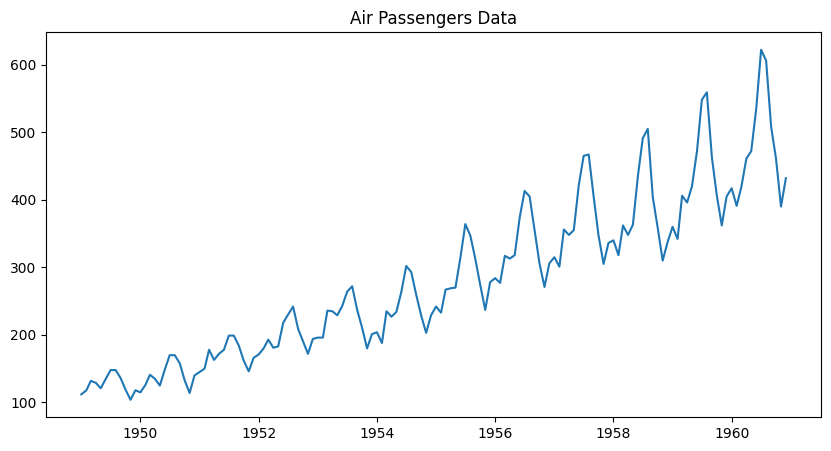

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df)
plt.title("Air Passengers Data")
plt.show()

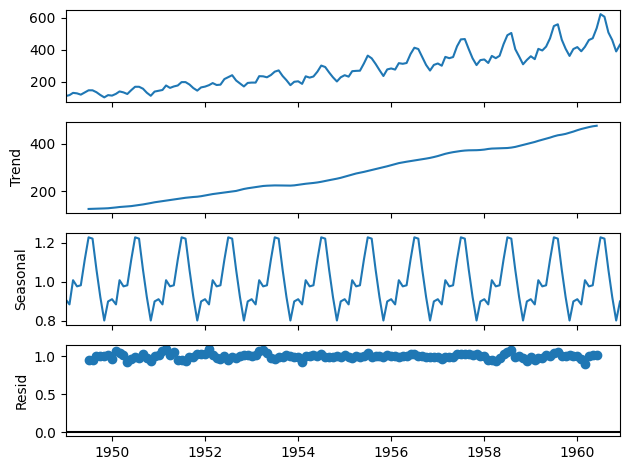

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df, model='multiplicative')

decomposition.plot()
plt.show()

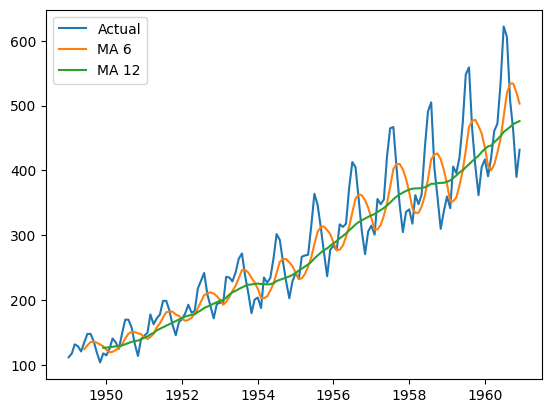

In [5]:
df['MA_6'] = df['Passengers'].rolling(window=6).mean()
df['MA_12'] = df['Passengers'].rolling(window=12).mean()

plt.plot(df['Passengers'], label='Actual')
plt.plot(df['MA_6'], label='MA 6')
plt.plot(df['MA_12'], label='MA 12')
plt.legend()
plt.show()

In [6]:
train = df.iloc[:-12]
test = df.iloc[-12:]

In [7]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Passengers'], order=(2,1,1))
model_fit = model.fit()

c:\Users\aarya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\aarya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\aarya\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [8]:
forecast = model_fit.forecast(steps=12)

In [9]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test['Passengers'], forecast))
print("RMSE:", rmse)

RMSE: 87.88437721096072


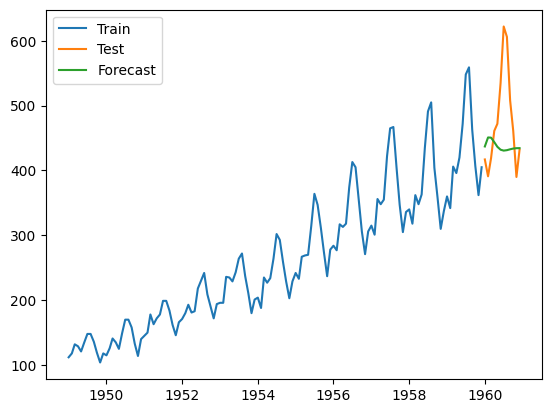

In [10]:
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.show()

In [11]:
df = pd.read_csv('../data/airline-passengers.csv', parse_dates=['Month'])
df.set_index('Month', inplace=True)